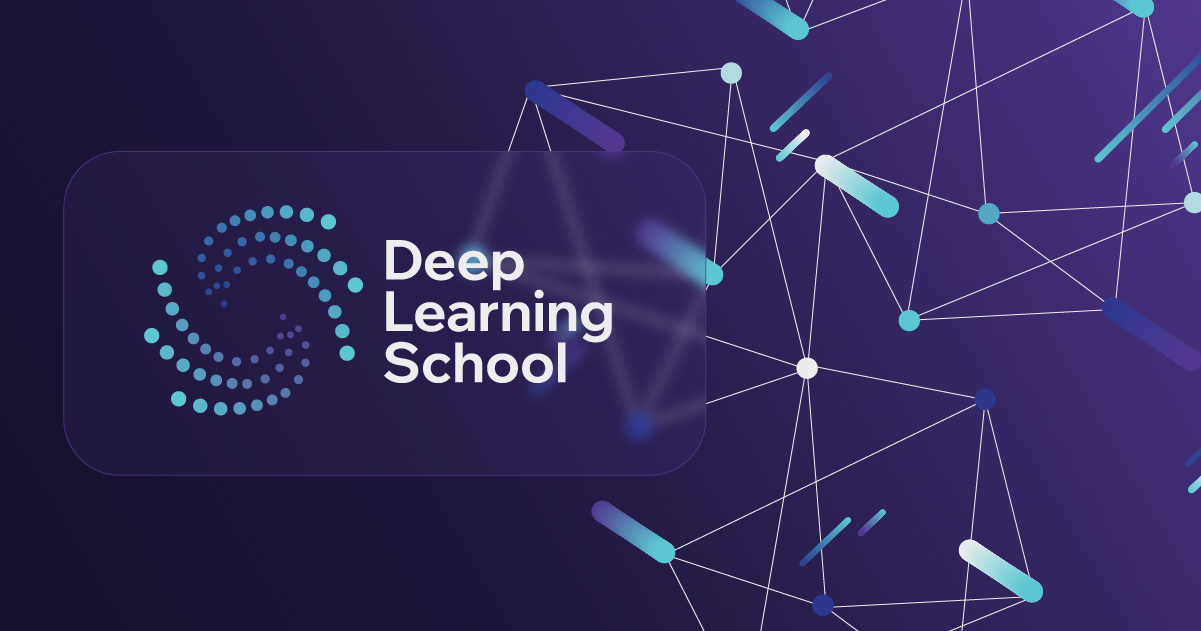

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Классификация изображений</b></h3>

https://www.kaggle.com/competitions/journey-to-springfield1

## Шаг 1. Установка зависимостей

#### Установим необходимые библиотеки и проверим доступность CUDA

In [ ]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [ ]:
!nvidia-smi

In [ ]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

#### Проверим версии Python и библиотек
Посмотрим, какие версии установлены:

In [ ]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.11.13
torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124
tqdm version: 4.67.1
matplotlib version: 3.7.2
seaborn version: 0.12.2
Pillow version: 11.3.0


 #### Определим константы, которые будем использовать в по ходу ноутбука

In [ ]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']

# работаем на видеокарте
DEVICE = torch.device("cuda")

#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('/content/train') #Path('./data/train/')
TEST_DIR = Path('/content/testset') #Path('./data/testset')

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

## Шаг 2. Загрузка и обработка данных

#### Скачаем изображения по ссылке

In [ ]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

In [ ]:
!unzip -q /content/journey-springfield.zip

В папке train лежат данные, которые будут использоваться для обучения модели. Изображения персонажей разложены по папкам, которые названы по именам персонажей. Названия папок в дальнейшем будут использоваться в качестве текстовых меток классов.

В папке testset находятся изображения, для которых нужно сделать прогноз наиболее вероятного класса.

Для обращения к файлам сформируем списки имен файлов обучающей+валидационнной и тестовой выборок. Это полные имена, включающие путь к файлам.

In [ ]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

Кодировать имена персонажей в числовые метки класса и обратно будем при помощи `LabelEncoder`.

Для train выборки сформируем список текстовых меток всех изображений - имя родительской директории, которая одновременно является и именем персонажа. Зададим числовые метки классов энкодера при помощи метода `fit`.

Далее применим метод `transform` для преобразования текстовых меток в числовые, и метод `inverse_transform` для преобразования числовых меток в текстовые.


In [ ]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

Разделим train выборку на обучающую и валидационнную части. Для того, чтобы персонажи были пропорционально представлены в обучающей и валидационнной подвыборках, применим стратификацию по меткам класса.

In [ ]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

#### Создание Datasets и Dataloaders

In [ ]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)


In [ ]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [ ]:
batch_size = 64

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

#### Посмотрим на изображения персонажей

Напишем функцию для визуализации картинок.

In [ ]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Проверим, как работает наша функция. Возьмем один батч из лоадера и подадим на вход функции первый тензор из этого батча. Заодно посмотрим, как работает кодировщик меток класса.

Числовая метка класса: 22
Текстовая метка класса: ['marge_simpson']


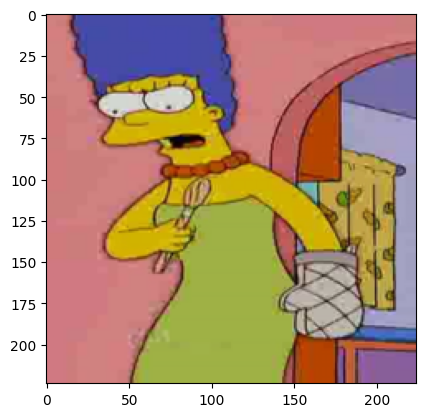

In [ ]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0],])}")
imshow(image_tensor[0])

Давайте посмотрим на наших героев внутри датасета.

In [ ]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
  return None

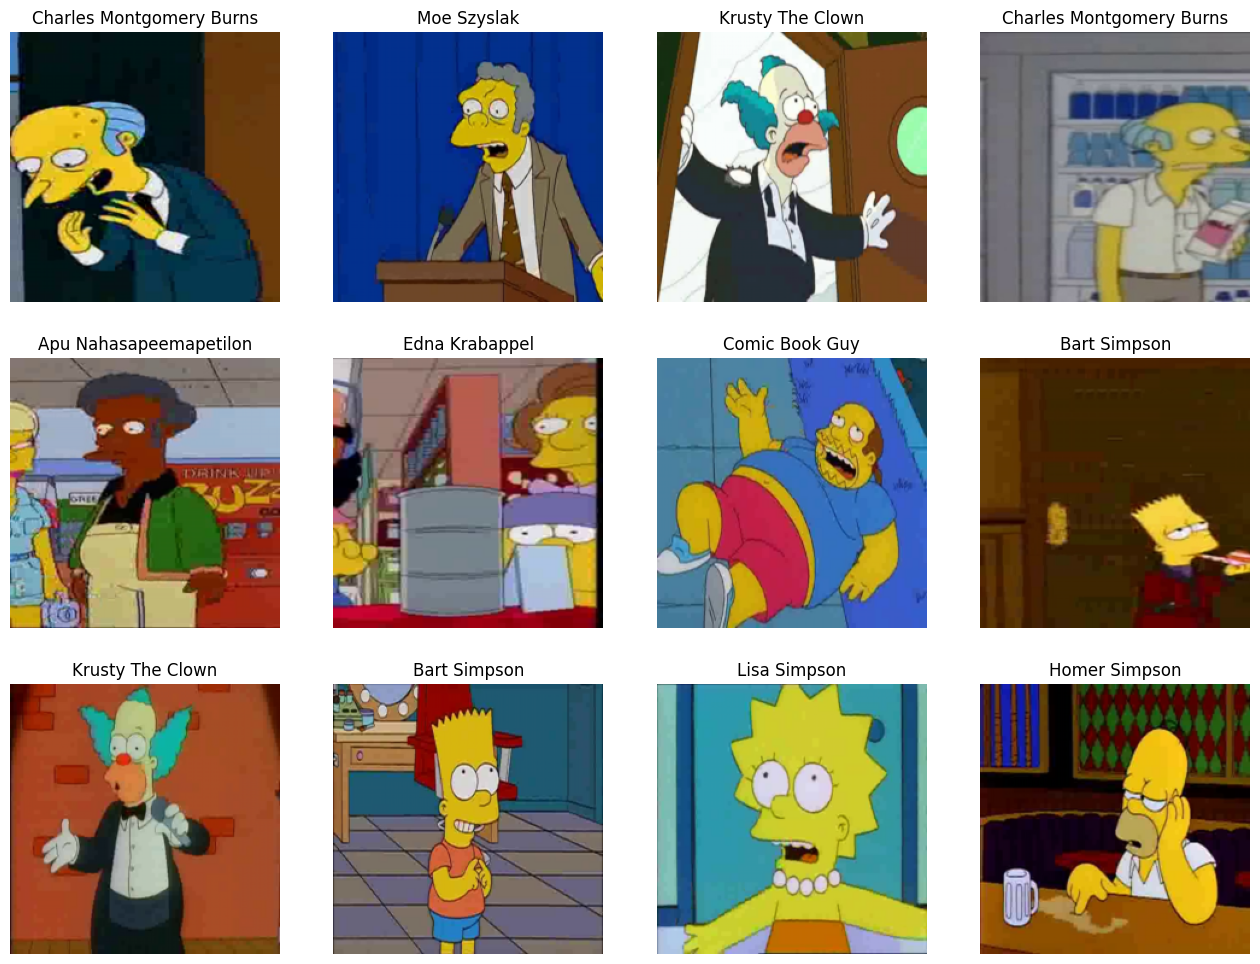

In [ ]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

## Шаг 3. Построение нейросети

#### Модель

In [ ]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

## Шаг 4. Функции для работы с моделью

In [ ]:
from sklearn.metrics import f1_score

Реализуем функции:
- для обучения модели на одной эпохе
- для валидации модели на одной эпохе
- для реализации полного цикла обучения

In [ ]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func, device):
  '''
  args:
    model - модель для обучения
    train_dataloader - loader с выборкой для обучения модели
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает метрику accuracy по эпохе на данных из train_dataloader
  '''

  model.train()

  y_train = torch.tensor([])
  preds = torch.tensor([])

  for X_batch, y_batch in tqdm(train_dataloader):

    optimizer.zero_grad()

    outp = model(X_batch.to(device))
    loss = loss_func(outp, y_batch.to(device))

    loss.backward()
    optimizer.step()

    y_train = torch.cat([y_train, y_batch], dim=0)
    preds = torch.cat([preds, outp.argmax(-1).cpu()], dim=0)

  return y_train, preds

In [ ]:
def eval_one_epoch(model, val_dataloader, device):
  '''
  args:
    model - модель для обучения
    val_dataloader - loader с валидационной/тестовой выборкой
  '''

  model.eval()

  y_valid = torch.tensor([])
  preds = torch.tensor([])

  for X_batch, y_batch in tqdm(val_dataloader):

    with torch.no_grad():
      outp = model(X_batch.to(device))

      y_valid = torch.cat([y_valid, y_batch], dim=0)
      preds = torch.cat([preds, outp.argmax(-1).cpu()], dim=0)

  return y_valid, preds

In [ ]:
def train_func(model, num_epochs, dataloaders, optimizer, loss_func, device):
  '''
  args:
    model - модель для обучения
    num_epochs - количество эпох
    dataloaders - словарь loader'ов с обучающей и валидационной выборками
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает accuracy на обучающей и валидационной выборках на каждой эпохе
  '''

  f1 = {"train": [], "valid": []}
  f1_train = 0
  f1_valid = 0

  for epoch in range(num_epochs):
    print(f"\nEpoch: {epoch+1}")

    y_train, preds_train = fit_one_epoch(
        model = model,
        train_dataloader = dataloaders['train'],
        optimizer = optimizer,
        loss_func = loss_func,
        device = device
    )

    f1_train = f1_score(y_train, preds_train, average='macro')
    print(f"f1_train: {f1_train}\n")

    y_valid, preds_valid = eval_one_epoch(
        model = model,
        val_dataloader = dataloaders['val'],
        device = device
    )

    f1_valid = f1_score(y_valid, preds_valid, average='macro')
    print(f"f1_valid: {f1_valid}\n")

    f1['train'].append(f1_train)
    f1['valid'].append(f1_valid)

  return f1

## Шаг 5. Применение модели к данным

#### Применение модели к данным

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)

Запуск обучения сети

In [ ]:
f1 = train_func(
    model = model_simple_cnn,
    num_epochs = 10,
    dataloaders = loaders,
    optimizer = optimizer,
    loss_func = criterion,
    device = DEVICE
)


Epoch: 1


100%|██████████| 246/246 [02:09<00:00,  1.89it/s]


f1_train: 0.11625274861736437



100%|██████████| 82/82 [00:39<00:00,  2.06it/s]


f1_valid: 0.21261123794837627


Epoch: 2


...

f1_valid: 0.64037038533593


Epoch: 10


100%|██████████| 246/246 [02:35<00:00,  1.58it/s]


f1_train: 0.9708932407844043



100%|██████████| 82/82 [00:43<00:00,  1.90it/s]

f1_valid: 0.632378213078797



График динамики метрик модели по ходу обучения

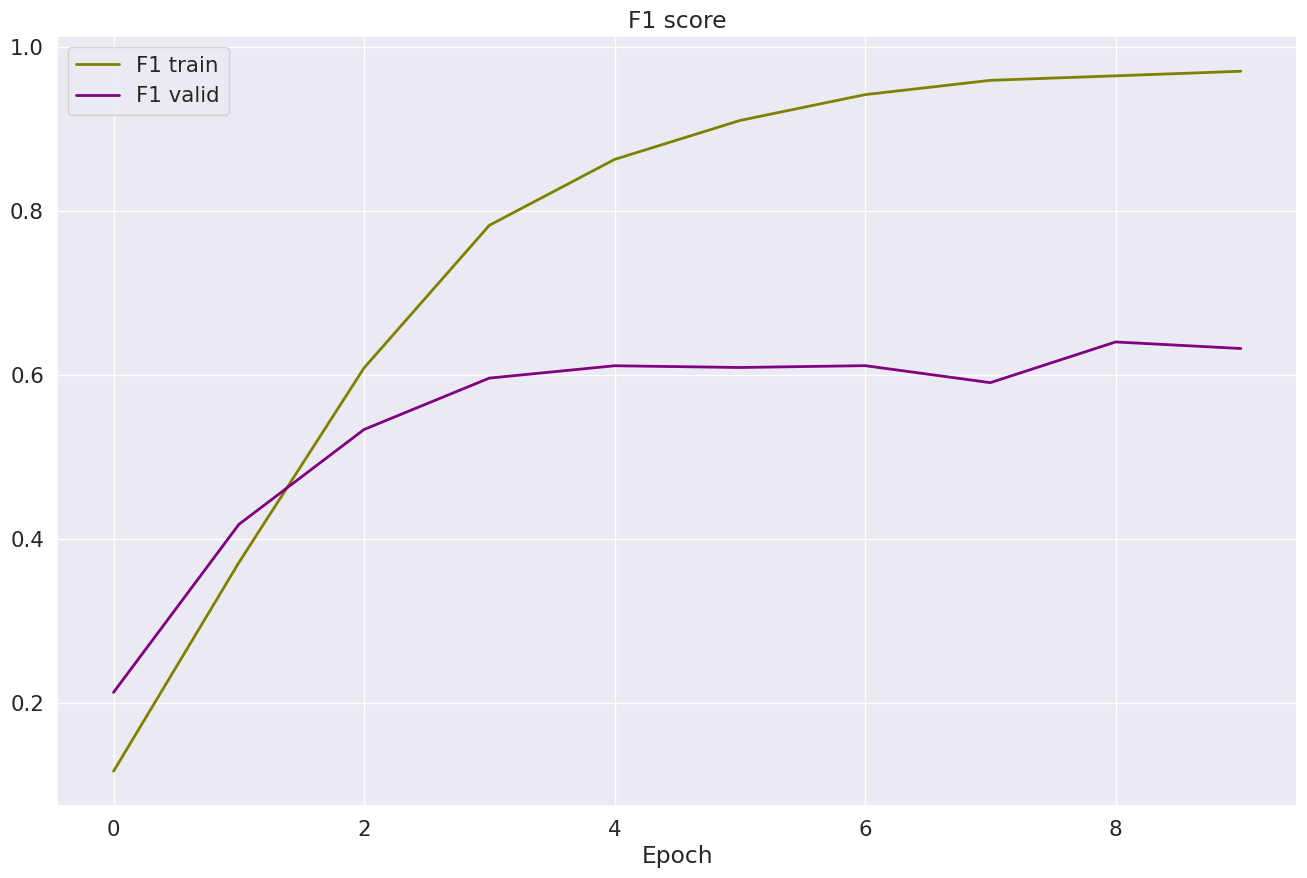

In [ ]:
import seaborn as sns

sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("F1 score")
plt.plot(range(10), f1['train'], label="F1 train", linewidth=2, color = 'olive')
plt.plot(range(10), f1['valid'], label="F1 valid", linewidth=2, color = 'purple')
plt.legend()
plt.xlabel("Epoch")
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Сделаем визуализацию, чтобы посмотреть насколько сеть уверена в своих ответах.

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in axs.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # выводим изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

    # ниже представлен код для добавления на изображение подписи с вероятностью класса
    actual_text = "Actual : {}".format(img_label)


    font0 = FontProperties()
    font = font0.copy()

    # модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100 # берем максимальную вероятность класса
    y_pred = np.argmax(prob_pred) # берем числовую метку класса, для которого вероятность максимальна

    predicted_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

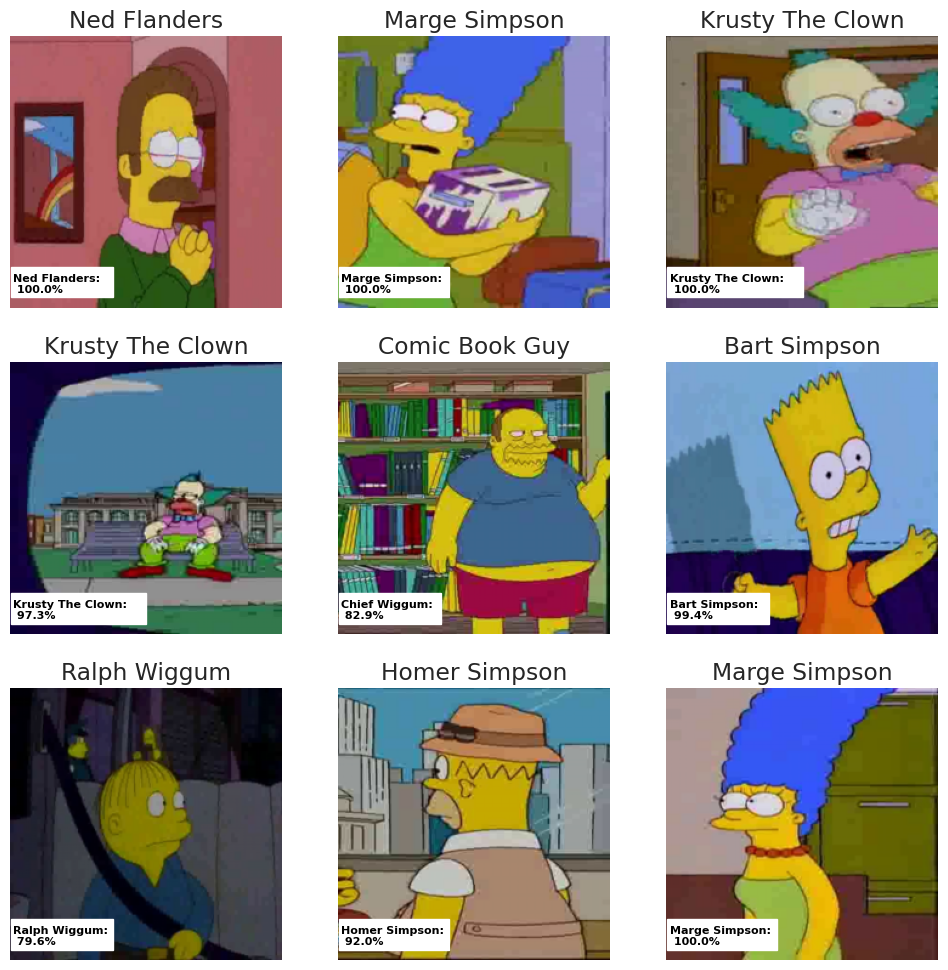

In [ ]:
show_images2(n_rows = 3, n_cols = 3, dataset = val_dataset, model = model_simple_cnn)

## Шаг 6. Submit на Kaggle

Создадим loader для тестовых данных

In [ ]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [ ]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

Получем предсказание меток классов для тестовых данных:

In [ ]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)

и преобразуем их в текстовые метки:

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Загрузим пример файла для загрузки на Kaggle:

In [ ]:
import pandas as pd
sample_submission = pd.read_csv("/content/sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [ ]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

In [ ]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

## Доработка baseline

> Попробуем доработать baseline для улучшения score.

> Начнем с класса для преобразования изображений в тензоры - увеличим разнообразие обучающей выборки при помощи аугментации. Добавим отражение по горизонтали (с вероятностью 0.5) и изменение цветовых характеристик изображений (яркость, контраст, насыщенность и оттенок).


In [ ]:
class SimpsonsDataset_v2(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            # добавим аугментацию
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)

In [ ]:
train_dataset = SimpsonsDataset_v2(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset_v2(val_files, label_encoder, mode='val')

In [ ]:
batch_size = 64

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

> Также немного изменим модель: увеличим количество каналов в сверточных слоях, чтобы модель могла извлекать более сложные признаки.
> Также добавим Batchnorm и Dropout для стабилизации обучения и предотвращения переобучения.



In [ ]:
class SimpleCnn_v2(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3), # увеличили out_channels с 8 до 16
            nn.BatchNorm2d(16), # добавлено
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3), # увеличили out_channels с 16 до 32
            nn.BatchNorm2d(32), # добавлено
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3), # увеличили out_channels с 32 до 64
            nn.BatchNorm2d(64), # добавлено
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3), # увеличили out_channels с 64 до 96
            nn.BatchNorm2d(96), # добавлено
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=3), # увеличили out_channels с 96 до 128
            nn.BatchNorm2d(128), # добавлено
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d(1) # для универсальности входных параметров
        self.dropout = nn.Dropout(0.5) # добавлено
        self.out = nn.Linear(128, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        logits = self.out(x)
        return logits

In [ ]:
model_simple_cnn = SimpleCnn_v2(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 222, 222]             448
       BatchNorm2d-2         [-1, 16, 222, 222]              32
              ReLU-3         [-1, 16, 222, 222]               0
         MaxPool2d-4         [-1, 16, 111, 111]               0
            Conv2d-5         [-1, 32, 109, 109]           4,640
       BatchNorm2d-6         [-1, 32, 109, 109]              64
              ReLU-7         [-1, 32, 109, 109]               0
         MaxPool2d-8           [-1, 32, 54, 54]               0
            Conv2d-9           [-1, 64, 52, 52]          18,496
      BatchNorm2d-10           [-1, 64, 52, 52]             128
             ReLU-11           [-1, 64, 52, 52]               0
        MaxPool2d-12           [-1, 64, 26, 26]               0
           Conv2d-13           [-1, 96, 24, 24]          55,392
      BatchNorm2d-14           [-1, 96,

> Для новой модели выберем оптимизатор AdamW и shduler OneCycleLR для изменения learning_rate во время обучения.



In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_v2 = optimizer = torch.optim.AdamW(
    model_simple_cnn.parameters(),
    lr=5e-4,
    weight_decay=1e-2
)

scheduler_v2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_v2,
    max_lr=3e-3,
    epochs=70,
    steps_per_epoch=len(loaders['train'])
)

> Также добавим изменение скорости обучения в функции обучения модели





In [ ]:
def fit_one_epoch_v2(model, train_dataloader, optimizer, loss_func, device, scheduler):
  '''
  args:
    model - модель для обучения
    train_dataloader - loader с выборкой для обучения модели
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает метрику accuracy по эпохе на данных из train_dataloader
  '''

  model.train()

  y_train = torch.tensor([])
  preds = torch.tensor([])

  for X_batch, y_batch in tqdm(train_dataloader):

    optimizer.zero_grad()

    outp = model(X_batch.to(device))
    loss = loss_func(outp, y_batch.to(device))

    loss.backward()
    optimizer.step()
    scheduler.step() # шаг leraning rate

    y_train = torch.cat([y_train, y_batch], dim=0)
    preds = torch.cat([preds, outp.argmax(-1).cpu()], dim=0)

  return y_train, preds

> В функцию полного цикла обучения добавим сохранение параметров модели с лучшим score после каждой эпохи. Также введем условия остановки при возникновении переобучения



In [ ]:
def train_func_v2(model, num_epochs, dataloaders, optimizer, loss_func, device, scheduler):
  '''
  args:
    model - модель для обучения
    num_epochs - количество эпох
    dataloaders - словарь loader'ов с обучающей и валидационной выборками
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает accuracy на обучающей и валидационной выборках на каждой эпохе
  '''

  f1 = {"train": [], "valid": []}
  f1_train = 0
  f1_valid = 0

  best_f1 = 0.0
  best_epoch = 0
  patience = 5

  for epoch in range(num_epochs):
    print(f"\nEpoch: {epoch+1}")

    y_train, preds_train = fit_one_epoch_v2(
        model = model,
        train_dataloader = dataloaders['train'],
        optimizer = optimizer,
        loss_func = loss_func,
        device = device,
        scheduler = scheduler
    )

    f1_train = f1_score(y_train, preds_train, average='macro')
    print(f"f1_train: {f1_train}\n")

    y_valid, preds_valid = eval_one_epoch(
        model = model,
        val_dataloader = dataloaders['val'],
        device = device
    )

    f1_valid = f1_score(y_valid, preds_valid, average='macro')
    print(f"f1_valid: {f1_valid}\n")

    f1['train'].append(f1_train)
    f1['valid'].append(f1_valid)

    # сохраняем параметры модели с лучшим score
    if f1_valid > best_f1:
        best_f1 = f1_valid
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Новый лучший F1: {best_f1:.4f}")
    # останавливаем обучение, если score не растет в течение patience эпох
    elif epoch - best_epoch >= patience:
        print(f"Ранний останов на эпохе {epoch}")
        break

  return f1

> Попробуем обучить дополненную модель



In [ ]:
f1 = train_func_v2(
    model = model_simple_cnn,
    num_epochs = 70,
    dataloaders = loaders,
    optimizer = optimizer_v2,
    loss_func = criterion,
    device = DEVICE,
    scheduler = scheduler_v2
  )


Epoch: 1


100%|██████████| 246/246 [06:05<00:00,  1.49s/it]


f1_train: 0.062014327734174604



100%|██████████| 82/82 [00:31<00:00,  2.57it/s]


f1_valid: 0.12196223665452675

Новый лучший F1: 0.1220

Epoch: 2


...

f1_valid: 0.8157861569535895


Epoch: 48


100%|██████████| 246/246 [06:13<00:00,  1.52s/it]


f1_train: 0.86882343110273



100%|██████████| 82/82 [00:31<00:00,  2.61it/s]

f1_valid: 0.8295647394879049

Ранний останов на эпохе 47


> Теперь дообучим нашу модель



In [ ]:
train_dataset = SimpsonsDataset_v2(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset_v2(val_files, label_encoder, mode='val')

In [ ]:
batch_size = 128

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

In [ ]:
model_simple_cnn = SimpleCnn_v2(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)

# Загружаем веса
model_simple_cnn.load_state_dict(torch.load('/content/best_model.pth', map_location=DEVICE))

<All keys matched successfully>

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_v3 = torch.optim.AdamW(
    model_simple_cnn.parameters(),
    lr=1e-5,           # уменьшим learning rate для более тонкой настройки
    weight_decay=1e-3
)

scheduler_v3 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_v3,
    max_lr=1e-4,          # пиковый learning rate также уменьшим
    epochs=40,
    steps_per_epoch=len(loaders['train'])
)

In [ ]:
f1 = train_func_v2(
      model = model_simple_cnn,
      num_epochs = 40,
      dataloaders = loaders,
      optimizer = optimizer_v3,
      loss_func = criterion,
      device = DEVICE,
      scheduler = scheduler_v3
)


Epoch: 1


100%|██████████| 123/123 [06:57<00:00,  3.39s/it]


f1_train: 0.8244940652733016



100%|██████████| 41/41 [00:47<00:00,  1.17s/it]


f1_valid: 0.9096744760365131

Новый лучший F1: 0.9097

Epoch: 2


...

f1_valid: 0.9306043624519357


Epoch: 18


100%|██████████| 123/123 [06:13<00:00,  3.03s/it]


f1_train: 0.872769612281194



100%|██████████| 41/41 [00:34<00:00,  1.19it/s]

f1_valid: 0.9282947289765509

Ранний останов на эпохе 17


> Теперь получаем предсказаение меток класса





In [ ]:
model_submit = SimpleCnn_v2(n_classes = len(np.unique(train_val_labels)))
model_submit.to(DEVICE)

# Загружаем веса
model_submit.load_state_dict(torch.load('/content/best_model.pth', map_location=DEVICE))

model_submit.eval()

SimpleCnn_v3(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [ ]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [ ]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

In [ ]:
predicted_numeric_labels = predict(model_submit, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

In [ ]:
sample_submission = pd.read_csv("/content/sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [ ]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [ ]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

Полученные результаты в соревновании kaggle:

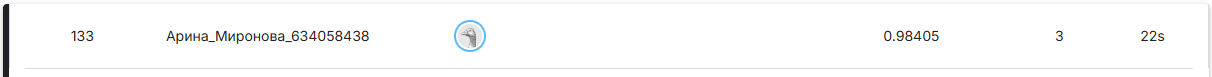